In [5]:
import torch

import torchvision
import os

from torchvision.datasets import CocoDetection
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.transforms import v2

torch.manual_seed(42)

In [6]:
class ValorantDataset(CocoDetection):
    def __getitem__(self, idx):
        img, anns = super().__getitem__(idx)

        
        boxes = []
        labels = []
        area = []
        iscrowd = []
        
        for a in anns:
            boxes.append(a["bbox"])
            labels.append(a["category_id"])
            area.append(a["area"])
            iscrowd.append(a["iscrowd"])
        
        if len(boxes) == 0:
            target = {
                'boxes': torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros((0,), dtype=torch.int64),
                'area': torch.zeros((0,), dtype=torch.float32),
                'iscrowd': torch.zeros((0,), dtype=torch.int64),
                'image_id': torch.tensor([idx]),
        }
        else:
            # Convert xywh → xyxy
            # print(anns)
            
            boxes = torch.tensor(boxes, dtype=torch.float32)
            boxes[:, 2:] = boxes[:, :2] + boxes[:, 2:]

            target = {
                "boxes": boxes,
                "labels": torch.tensor(labels, dtype=torch.int64),
                "area": torch.tensor(area, dtype=torch.float32),
                "iscrowd": torch.tensor(iscrowd, dtype=torch.int64),
                "image_id": torch.tensor([idx])
            }

        return img, target


In [7]:
transforms = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
        
        #v2.ToTensor() is deprecated
    ]
)

TRAIN = ValorantDataset(
    root=os.path.join("..", "data", "train"),
    annFile=os.path.join("..", "data", "train", "_annotations.coco.json"),
    transforms=transforms,
)

VALIDATION = ValorantDataset(
    root=os.path.join("..", "data", "valid"),
    annFile=os.path.join("..", "data", "valid", "_annotations.coco.json"),
    transforms=transforms,
)
TEST = ValorantDataset(
    root=os.path.join("..", "data", "test"),
    annFile=os.path.join("..", "data", "test", "_annotations.coco.json"),
    transforms=transforms,
)


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [8]:
num_classes = 2 + 1 # 2 classes + background

model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
# in_features = model.roi_heads.box_predictor.cls_score.in_features
# model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
# in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
# hidden_layer = 256
# model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [9]:
train_dataloader = torch.utils.data.DataLoader(
    TRAIN,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x)),
)

valid_dataloader = torch.utils.data.DataLoader(
    VALIDATION,
    batch_size=2,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x)),
)

In [10]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.0005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

num_epochs = 1

In [92]:
batch_images, batch_targets = next(iter(train_dataloader))
batch_images = list(image.to(device) for image in batch_images)
batch_targets = [{k: v.to(device) for k, v in t.items()} for t in batch_targets]

In [11]:
def save_checkpoint(model, optimizer, lr_scheduler, epoch, loss, batch_idx, path="checkpoint.pth"):
    checkpoint = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "lr_scheduler": lr_scheduler.state_dict(),
        "epoch": epoch,
        "loss": loss,
        "batch_idx": batch_idx,
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved to {path}")

ckpt_path = "checkpoint.pth"

In [ ]:
total_loss = []
for epoch in range(num_epochs):
    model.train()
    i = 0
    if os.path.exists(ckpt_path):
        checkpoint = torch.load(ckpt_path, map_location=device)

        model.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        lr_scheduler.load_state_dict(checkpoint["lr_scheduler"])
        start_epoch = checkpoint["epoch"] + 1
        start_batch = checkpoint["batch_idx"] + 1
        total_loss = checkpoint["loss"]
        
        print(f"Resuming from epoch {start_epoch}")
    
    for i, (images, targets) in enumerate(train_dataloader):
        if epoch == start_epoch and i < start_batch:
            continue  # skip processed batches

        images = list(image.to(device) for image in images)
        # targets = list(t.to(device) for t in targets) 
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        # print(targets[0])
        # targets = [{k: v.to(device) for k, v in t[0].items()} for t in targets]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())
        total_loss.append(losses.item())
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if i % 10 == 0:
            save_checkpoint(model, optimizer, lr_scheduler, epoch, total_loss, batch_idx=i)
            print(f"Epoch: {epoch} | Iteration: {i} | Loss: {losses.item()}")
        i += 1

    lr_scheduler.step()

save_checkpoint(model, optimizer, lr_scheduler, epoch, total_loss, batch_idx=i)
print(f"Epoch: {epoch} | Iteration: {i} | Loss: {losses.item()}")

Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 0 | Loss: 0.3329891860485077
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 10 | Loss: 0.49713486433029175
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 20 | Loss: 0.39439836144447327
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 30 | Loss: 0.47740960121154785
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 40 | Loss: 0.678636908531189
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 50 | Loss: 0.28334832191467285
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 60 | Loss: 0.23871897161006927
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 70 | Loss: 0.40028703212738037
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 80 | Loss: 0.4441123604774475
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 90 | Loss: 0.22752922773361206
Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 100 | Loss: 0.3225633203983307
Checkpoint saved to checkpoint.pth
Ep

In [16]:
average_loss = sum(total_loss) / len(total_loss)
print(f"Training completed. Average Loss: {average_loss}")

Training completed. Average Loss: 0.24443151406529878


In [15]:
save_checkpoint(model, optimizer, lr_scheduler, epoch, total_loss, batch_idx=i)
print(f"Epoch: {epoch} | Iteration: {i} | Loss: {losses.item()}")

Checkpoint saved to checkpoint.pth
Epoch: 0 | Iteration: 720 | Loss: 0.18379122018814087


### Evaluation

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [ ]:
model.eval()
with torch.no_grad():
    for images, targets in valid_dataloader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)

        

In [20]:
image, target = next(iter(train_dataloader))
model.eval()
image = list(img.to(device) for img in image)
preds = model(image)

In [21]:
boxes = preds[0]['boxes'].cpu().detach().numpy()
scores = preds[0]['scores'].cpu().detach().numpy()
labels = preds[0]['labels'].cpu().detach().numpy()

filtered = [(box, score, label) for box, score, label in zip(boxes, scores, labels) if score > 0.8]

actual_boxes = target[0]['boxes'].numpy()
actual_labels = target[0]['labels'].numpy()

image_for_plotting = list(img.cpu().permute(1, 2, 0).numpy() for img in image)

In [22]:
preds

[{'boxes': tensor([[265.2604, 116.7604, 282.6052, 159.0388],
          [270.1544, 117.5382, 276.5617, 124.6792],
          [359.4509, 158.9302, 476.3427, 286.7875],
          [407.0760,  26.4612, 416.4350,  38.9775],
          [270.1305, 120.0070, 276.1197, 126.8135],
          [270.5280, 125.6559, 276.8970, 133.3708]], device='cuda:0',
         grad_fn=<StackBackward0>),
  'labels': tensor([1, 2, 1, 1, 2, 2], device='cuda:0'),
  'scores': tensor([0.9796, 0.9794, 0.4380, 0.1085, 0.0971, 0.0799], device='cuda:0',
         grad_fn=<IndexBackward0>)},
 {'boxes': tensor([[259.7882, 139.4834, 266.5926, 154.2267],
          [314.6030, 159.9121, 325.2206, 179.9073],
          [376.8432, 175.8617, 383.7399, 184.4227],
          [314.7108, 159.9938, 325.1954, 180.1887],
          [398.8332,  56.6770, 406.8073,  63.9912]], device='cuda:0',
         grad_fn=<StackBackward0>),
  'labels': tensor([1, 2, 2, 4, 2], device='cuda:0'),
  'scores': tensor([0.7228, 0.2546, 0.2417, 0.0659, 0.0648], device=

In [23]:
filtered

[(array([265.26044, 116.76035, 282.60522, 159.03877], dtype=float32),
  np.float32(0.97960126),
  np.int64(1)),
 (array([270.15442 , 117.538246, 276.56174 , 124.679214], dtype=float32),
  np.float32(0.97942597),
  np.int64(2))]

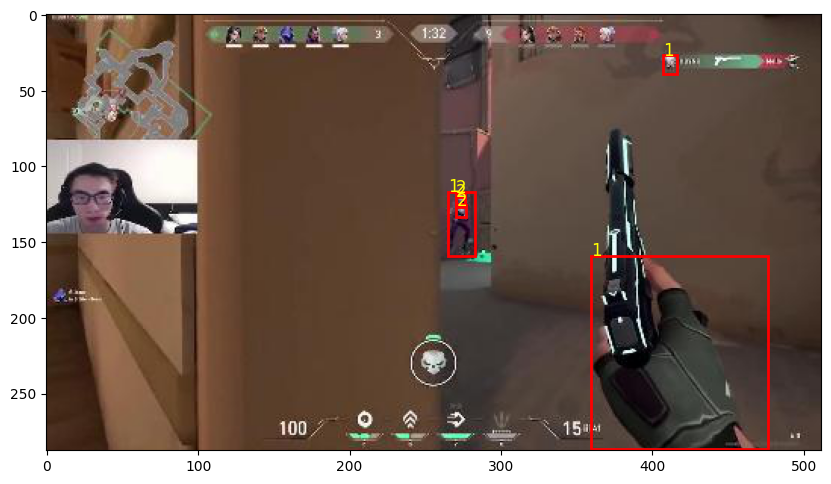

In [24]:
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(image_for_plotting[0])

for box, label in zip(boxes, labels):
    x1, y1, x2, y2 = box.tolist()
    w = x2 - x1
    h = y2 - y1

    rect = patches.Rectangle(
        (x1, y1), w, h,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1, str(int(label)), color='yellow', fontsize=12)

plt.show()